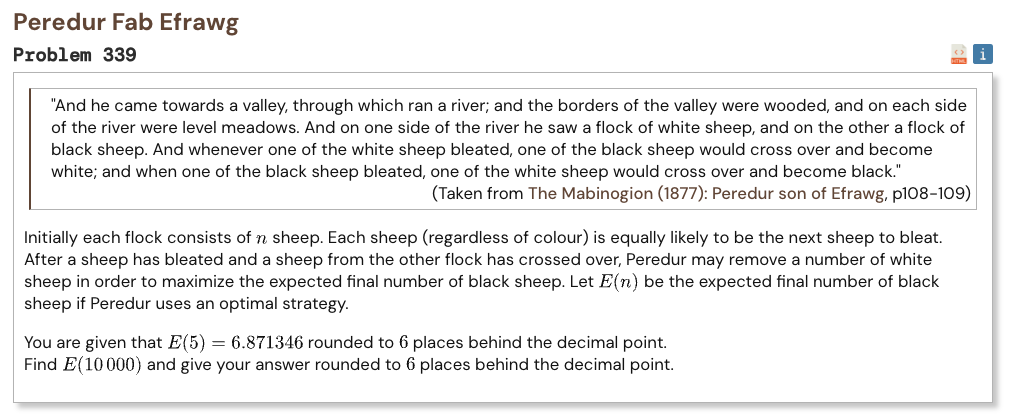

## Initial approach

* treat the process as an optimal stopping problem
* after each colour change, Peredur may remove white sheep again
* the best strategy creates a stopping boundary near the middle
* this reduces the full state space to a one-dimensional recurrence
* update the midpoint value step by step
* use central binomial probability ratios instead of huge binomial numbers
* test the given value for n = 5 before solving n = 10000

In [1]:
def expected_black(n):
    B = [0.0] * (n + 1)
    p = 1.0

    for b in range(1, n + 1):
        ratio = (2.0 * p) / (1.0 + p)
        m = 2 * b - 1
        B[b] = B[b - 1] + (m - B[b - 1]) * ratio
        p *= (2.0 * b - 1.0) / (2.0 * b)

    q = 0.5

    for t in range(1, n):
        q *= (2.0 * t + 1.0) / (2.0 * t + 2.0)

    ratio = 2.0 * q
    m = 2 * n
    value_right = B[n] + (m - B[n]) * ratio

    return 0.5 * (B[n - 1] + value_right)

def solve():
    return expected_black(10000)

assert abs(expected_black(5) - 6.871346) < 5e-7

In [2]:
%%time
result = solve()
print("Result:", f"{result:.6f}")

Result: 19823.542204
CPU times: user 2.25 ms, sys: 118 μs, total: 2.37 ms
Wall time: 2.48 ms
